# Tarea 1 — Introducción a Métodos Numéricos

Bienvenido. Esta tarea se contesta directamente en Google Colab.

Al ejecutar la celda de configuración, Google te pedirá permiso para acceder a tu Drive.

> INICIA SESIÓN CON TU CORREO INSTITUCIONAL

- Debe ser un correo que termine en **@campus.tecnm.mx**.
- Si no es institucional, verás una alerta y no podrás continuar.
- Es importante para identificarte y validar la tarea.

Además, solo se necesita seleccionar la **primera opción** una sola vez, pero no hay problema si seleccionas todo aquí porque este código es seguro.

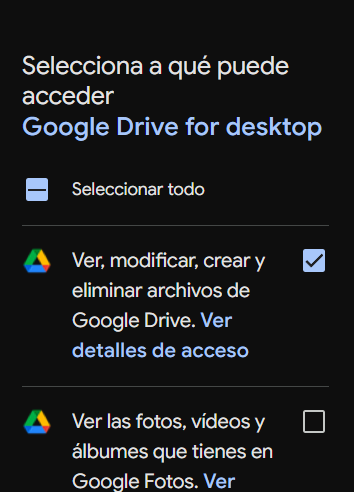

Si haz ejecutado esta celda varias veces, puede seguirte preguntando por los otros permisos, pero puedes continuar sin seleccionarlos.

In [1]:
# @title Ejecutar configuración general
# ============================================================
# CELDA 1 — CONFIGURACIÓN GENERAL (NO MODIFICAR)
# Detecta si corre en Google Colab o en tu computadora.
# ============================================================
import os, sys, subprocess, importlib, base64, zlib

# ¿Estamos en Google Colab?
try:
    import google.colab
    ES_COLAB = True
except ImportError:
    ES_COLAB = False

# Configuración del repositorio  <-- EDITAR ESTOS VALORES
REPO_URL = 'https://github.com/ITH-MGL-MN/1_1_Introduccion.git'
REPO_NOMBRE = '1_1_Introduccion'

if ES_COLAB:
    BASE = '/content/drive/MyDrive/CursoMN'
    REPO = os.path.join(BASE, REPO_NOMBRE)
else:
    # En local, buscar la carpeta de la tarea (la que contiene profe/grader.py)
    # subiendo de carpeta en carpeta desde la actual.
    REPO = os.getcwd()
    for _ in range(4):
        if os.path.exists(os.path.join(REPO, 'profe', 'grader.py')):
            break
        padre = os.path.dirname(REPO)
        if padre == REPO:
            break
        REPO = padre
    # Respaldo: ruta local de la tarea en tu Google Drive (ajústala si cambiaste)
    if not os.path.exists(os.path.join(REPO, 'profe', 'grader.py')):
        REPO = r'o:\Mi unidad\CursoMN\1_1_Introduccion'

print('Modo:', 'Google Colab' if ES_COLAB else 'PC local')
print('Carpeta de la tarea:', REPO)

# ============================================================
# Montar Drive y descargar el repo.
# (En tu computadora no hace nada).
# ============================================================
if ES_COLAB:
    from google.colab import drive

    # Montar Drive y clonar/actualizar el repositorio
    drive.mount('/content/drive')
    os.makedirs(BASE, exist_ok=True)
    if not os.path.exists(REPO):
        subprocess.run(['git', 'clone', REPO_URL, REPO])
    else:
        subprocess.run(['git', '-C', REPO, 'pull'])
    print('✅ Repositorio listo en Drive.')
else:
    print('Modo local: no se monta Drive.')

# ============================================================
# INSTALAR LIBRERÍAS Y CARGAR LA LÓGICA PRINCIPAL
# (Funciona igual en Colab y en tu computadora).
# ============================================================
# 1) Instalar librerías necesarias
for pkg in ['sympy', 'numpy', 'scipy', 'matplotlib', 'requests', 'ipywidgets']:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# 2) Añadir rutas al path (las utilidades viven en lib/)
sys.path.insert(0, os.path.join(REPO, 'lib'))

# 3) Precargar sintaxis estilo MATLAB
with open(os.path.join(REPO, 'lib', 'matlab_like.py'), encoding='utf-8') as f:
    exec(f.read(), globals())

# 4) Funciones matemáticas 'inteligentes' (SymPy + NumPy)
from robomat import M, I, sin, cos, tan, var, rad, deg, evaluar, mostrar, jacobiano

# 5) Cargar la lógica del calificador
#    - Google Colab: versión OFUSCADA (grader_ofuscado.txt)
#    - Tu computadora (debug): código FUENTE sin ofuscar (profe/grader.py)
if ES_COLAB:
    with open(os.path.join(REPO, 'grader_ofuscado.txt'), encoding='utf-8') as f:
        blob = f.read().strip()
    codigo = zlib.decompress(base64.b64decode(blob)).decode('utf-8')
else:
    # Debug local: editar aquí / poner print para ver qué pasa
    ruta_grader = os.path.join(REPO, 'profe', 'grader.py')
    with open(ruta_grader, encoding='utf-8') as f:
        codigo = f.read()
    print('🔧 Modo debug local: cargando profe/grader.py (sin ofuscar)')

exec(codigo, globals())

print('✅ Entorno listo. Sigue las instrucciones de las siguientes celdas.')

Modo: PC local
Carpeta de la tarea: o:\Mi unidad\CursoMN\1_1_Introduccion
Modo local: no se monta Drive.
🔧 Modo debug local: cargando profe/grader.py (sin ofuscar)
✅ Entorno listo. Sigue las instrucciones de las siguientes celdas.


## Identifícate

Te identificarás automáticamente con la cuenta institucional con la que montaste
Google Drive.

In [2]:
# @title
# ============================================================
# IDENTIFICACIÓN AUTOMÁTICA
# Usa tu correo institucional (…@….tecnm.mx) como identificador.
# ============================================================
if ES_COLAB:
    import requests
    from google.colab import auth
    import google.auth
    import google.auth.transport.requests

    # Autenticación explícita para asegurar el acceso a la identidad
    try:
        auth.authenticate_user()
        creds, _ = google.auth.default()
        auth_request = google.auth.transport.requests.Request()
        creds.refresh(auth_request)

        info = requests.get(
            'https://www.googleapis.com/drive/v3/about?fields=user',
            headers={'Authorization': 'Bearer ' + creds.token},
            timeout=20,
        ).json()
        email = info.get('user', {}).get('emailAddress', '')
    except Exception as e:
        print('⚠️ No se pudo obtener tu correo automáticamente.')
        print('Asegúrate de permitir el acceso en la ventana emergente.')
        print('Detalle:', e)
        email = ''
else:
    # Modo local (pruebas): escribe un correo manualmente
    email = input('Correo institucional (pruebas): ').strip()

if email and ('@' in email) and email.lower().endswith('.tecnm.mx'):
    alumno_id = email
    print('✅ Identificado: ' + email)
    print('Tu ID de semilla es: ' + alumno_id)
elif not email:
    print('No se pudo identificar el correo. Por favor, vuelve a intentar.')
    alumno_id = None
else:
    from IPython.display import display, HTML
    display(HTML(
        '<p style="color:#b00020;background:#ffe0e0;padding:12px;border-radius:8px;'
        'font-weight:bold">⛔ Este correo no es institucional.<br>'
        'Usa tu cuenta @campus.tecnm.mx. Si iniciaste con otra cuenta, '
        'cierra sesión o usa una ventana de incógnito.</p>'
    ))
    print('Correo detectado: ' + email)
    alumno_id = None

✅ Identificado: jesus.medinag@hermosillo.tecnm.mx
Tu ID de semilla es: jesus.medinag@hermosillo.tecnm.mx


# Guarda el Notebook
Una vez completado, debes guardar este archivo para no tener problemas si se te va el internet mientras lo contestas. Se creó una carpeta en tu Google Drive llamada `CursoMN/1_1_Introduccion` para esta tarea.

ve a `Archivo → Guardar una copia en Drive` y selecciona `CursoMN/1_1_Introduccion` para conservar tu trabajo.

# Consigue un teclado adecuado
A pesar de que puedes trabajar sin problemas usando el teclado actual, recomiendo usar uno para programar, como [Coding Keyboard forProgramming](https://play.google.com/store/apps/details?id=com.ajay.prokeyboard&pcampaignid=web_share).

Personalmente, prefiero que trabajen usando la computadora o con un teclado bluetooth/USB C, pero se puede trabajar perfectamente en el celular.

## Pregunta 1

Ejecuta la celda siguiente para ver tu primera pregunta.

In [ ]:
# ============================================================
# PREGUNTA 1
# ============================================================
pregunta(1)

## 📝 Tu examen personalizado

#### Pregunta 1: Resta sencilla

<IPython.core.display.Math object>

Guarda el resultado en `r1`.

#### Pregunta 2: Multiplicación sencilla

<IPython.core.display.Math object>

Guarda el resultado en `r2`.

#### Pregunta 3: Suma sencilla

<IPython.core.display.Math object>

Guarda el resultado en `r3`.

## Escribe la respuesta 1

Escribe el resultado en la variable `r1` y ejecuta la celda.

In [ ]:
# ============================================================
# RESPUESTA 1  <- escribe aquí tu respuesta
# ============================================================
r1 = None

## Pregunta 2

Ejecuta la celda siguiente para ver tu segunda pregunta.

In [ ]:
# ============================================================
# PREGUNTA 2
# ============================================================
pregunta(2)

## Escribe la respuesta 2

Escribe el resultado en la variable `r2` y ejecuta la celda.

In [ ]:
# ============================================================
# RESPUESTA 2  <- escribe aquí tu respuesta
# ============================================================
r2 = None

## Pregunta 3

Ejecuta la celda siguiente para ver tu tercera pregunta.

In [ ]:
# ============================================================
# PREGUNTA 3
# ============================================================
pregunta(3)

## Escribe la respuesta 3

Escribe el resultado en la variable `r3` y ejecuta la celda.

In [ ]:
# ============================================================
# RESPUESTA 3  <- escribe aquí tu respuesta
# ============================================================
r3 = None

## Verifica

Ejecuta la siguiente celda para obtener retroalimentación inmediata.

In [ ]:
# ============================================================
# VERIFICA (feedback inmediato)
# ============================================================
calificar()

## Enviar

Ejecuta la siguiente celda para enviar tus resultados.
**Solo se puede enviar una vez.**

In [ ]:
# ============================================================
# ENVIAR (solo una vez)
# ============================================================
enviar()